In [1]:
from   matplotlib        import pyplot as plt
from   scipy.interpolate import CubicSpline
import numpy             as np
from   UTILS             import InitialCondition, InitialCondition_3d
from   scipy.stats       import maxwell

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


# Costants

In [2]:
# Constants class, values are loaded from UTILS.py
from UTILS import mass, dt, bohr_magneton, kB
from UTILS import Temperature, Temperature_transv
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from UTILS import harmonic_degree, harmonic_coefficient

In [3]:
Temperature        = 5e-3 # K
Temperature_transv = 10e-3 # K
theta              = 20
tau_mixing         = 1
stringa            = ""

class constants:
    def __init__(self, 
                 mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing):
        self.mass = mass
        self.dt = dt
        self.bohr_magneton = bohr_magneton
        self.kB = kB
        self.Temperature = Temperature
        self.Temperature_transv = Temperature_transv
        self.Zmin = Zmin
        self.Zmax = Zmax
        self.Zmid = Zmid
        self.zacceptance_min = zacceptance_min
        self.zacceptance_max = zacceptance_max
        self.harmonic_degree = harmonic_degree
        self.harmonic_coefficient = harmonic_coefficient
        self.tau_mixing = tau_mixing
    mu_eff_over_m = bohr_magneton / mass

CONSTANTS = constants(mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing)

print(CONSTANTS.Temperature, CONSTANTS.Temperature_transv)

0.005 0.01


# Functions to make the plot nicer

In [4]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

# TEST ENERGY, POSITION, MAGNETIC FIELD MAPS

## Boltzmann-Maxwell distribution

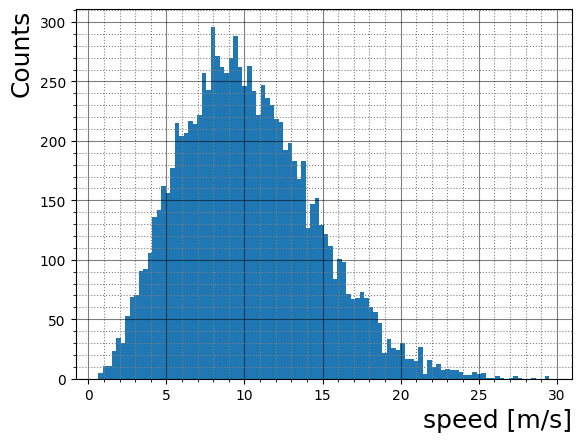

In [5]:
scale = np.sqrt(CONSTANTS.kB * CONSTANTS.Temperature/CONSTANTS.mass)
sampling = maxwell.rvs(scale = scale, size = 10000)
plt.hist(sampling, bins = 100)
plotter_nicer("speed [m/s]", "Counts")

## Plot of the Magnetic field profile, 20mT well

In [6]:
data = np.genfromtxt("Bfield_notebook/PreGravity_20mT_well_0p0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000

print(type(data))
print(10*"-")
print(data)
print(10*"-")
print(data[0])
print(10*"-")
print(data[0][0], data[0][1] )
print(10*"-")
print(data["z_mm__Bz_on_axis"])
#Z, Potential, Z_minwall, PotentialMinWall 

<class 'numpy.ndarray'>
----------
[(-2599.48, 0.00118259) (-2598.96, 0.0011841 ) (-2598.44, 0.00118563) ...
 ( 2598.44, 0.00138514) ( 2598.96, 0.0013834 ) ( 2599.48, 0.00138165)]
----------
(-2599.48, 0.00118259)
----------
-2599.4799999999996 0.001182594539963945
----------
[-2599.48 -2598.96 -2598.44 ...  2598.44  2598.96  2599.48]


<ErrorbarContainer object of 3 artists>

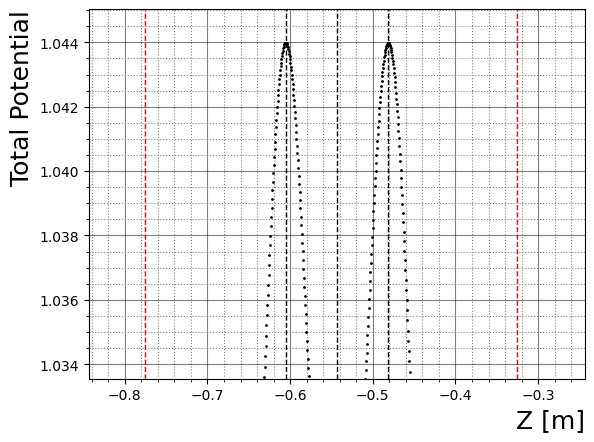

In [7]:
plotter_nicer("Z [m]", "Total Potential")

plt.xlim(CONSTANTS.Zmid -0.3, CONSTANTS.Zmid + 0.3)
massimo = np.max(data["Total_potential_T__Bz_on_axis"]); plt.ylim(massimo*0.990, massimo*1.001)

plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_min, linestyle = "--", color = "red", linewidth = 1)
plt.axvline(CONSTANTS.zacceptance_max, linestyle = "--", color = "red", linewidth = 1)
plt.errorbar(data['z_mm__Bz_on_axis']/1000,data["Total_potential_T__Bz_on_axis"], linestyle = '', marker = '.', markersize = 2, color = "black")

## Spline Creation

- **Bfield(x)** Magnetic Field Potential

In [8]:
Z = data['z_mm__Bz_on_axis']/1000
print(Z)
Uz = data["Total_potential_T__Bz_on_axis"]

# # Modify the potential to check the bias
# mask = (Z > -0.5) & (Z < -0.47)
# Uz[mask] = Uz[mask]# + 0.00007

Bfield = CubicSpline(Z, Uz)

[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948]


ERROR! Session/line number was not unique in database. History logging moved to new session 115


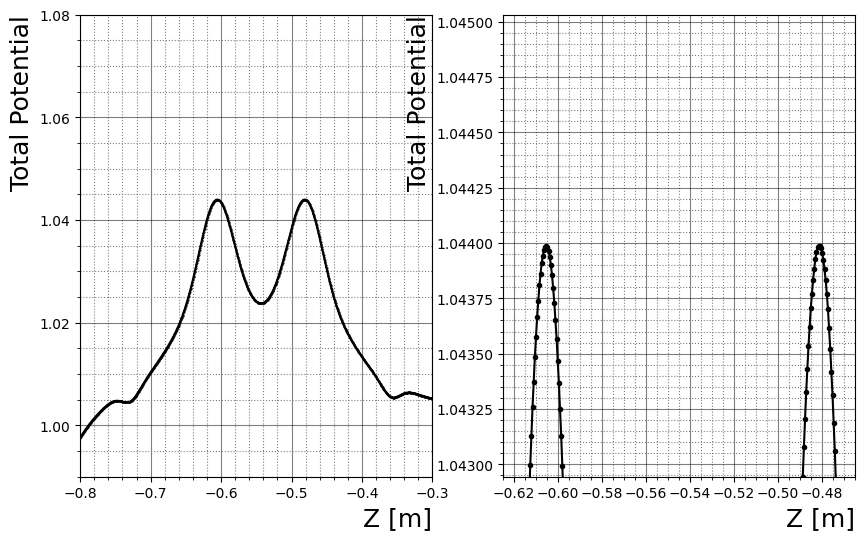

In [9]:
plt.figure(1243, figsize = (10, 6))
plt.subplot(1,2,1)
plotter_nicer("Z [m]", "Total Potential")

plt.xlim(-0.800, -0.300)
plt.ylim(.99, 1.08)

plt.plot(Z, Bfield(Z), linestyle = "-", linewidth = 0.5, color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"], marker = ".", markersize = 1, color = "black")

plt.subplot(1,2,2)
plotter_nicer("Z [m]", "Total Potential")

plt.xlim(-0.625, -0.465)
massimo = np.max(data["Total_potential_T__Bz_on_axis"]); plt.ylim(massimo*0.999, massimo*1.001)

plt.plot(Z, Bfield(Z), linestyle = "-", linewidth = 0.5, color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"], marker = ".", color = "black")

## Energy Distribution

In [10]:
from scipy.optimize import brentq

<ErrorbarContainer object of 3 artists>

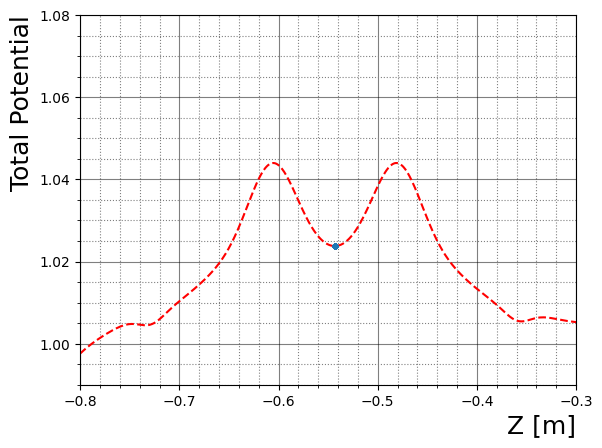

In [11]:
nAtoms = 100

Zinit = [InitialCondition_3d(Bfield, CONSTANTS)[1][2] for i in range(0,nAtoms)]

plotter_nicer("Z [m]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(.99, 1.08)
plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.errorbar(Zinit, Bfield(Zinit), linestyle = "", marker = ".")

(array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 1000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.]),
 array([-1.0434, -0.9934, -0.9434, -0.8934, -0.8434, -0.7934, -0.7434,
        -0.6934, -0.6434, -0.5934, -0.5434, -0.4934, -0.4434, -0.3934,
        -0.3434, -0.2934, -0.2434, -0.1934, -0.1434, -0.0934, -0.0434]),
 <BarContainer object of 20 artists>)

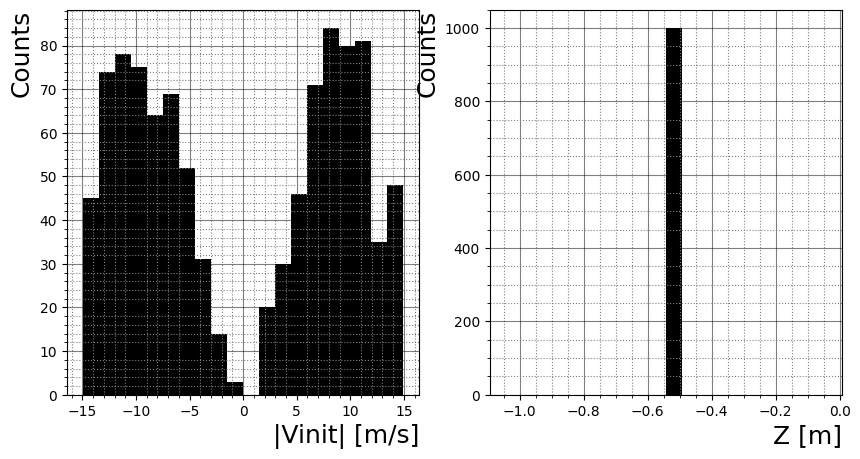

In [12]:
nAtoms = 1000

Vinit = []
Xinit = []

for i in range(1):
    for i in range(0,nAtoms):
        tmp0, tmp1 = InitialCondition_3d(Bfield, CONSTANTS)
        Xinit.append(tmp1)
        Vinit.append(tmp0)

Xinit = np.array(Xinit)
Vinit = np.array(Vinit)

#print(Vinit)
#print(Vinit[:,2])
#print(Xinit)

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plotter_nicer("|Vinit| [m/s]", "Counts")
plt.hist(Vinit[:,2], bins = 20, linestyle = "--", color = "black")

plt.subplot(1,2,2)
plotter_nicer("Z [m]", "Counts")
plt.hist(Xinit[:,2], bins = 20, linestyle = "--", color = "black")

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# from matplotlib import rc
# rc('animation', html='jshtml')

# fig, ax = plt.subplots()
# x = np.linspace(0, 2*np.pi, 200)
# pt, = ax.plot([], [], 'o')
# ax.set_xlim(0, 2*np.pi)
# ax.set_ylim(-1.2, 1.2)

# def init():
#     pt.set_data([], [])
#     return (pt,)

# def update(i):
#     t = i/30
#     pt.set_data([t%(2*np.pi)], [np.sin(t)])
#     return (pt,)

# ani = FuncAnimation(fig, update, init_func=init, frames=300, interval=20, blit=True)
# plt.close(fig)
# HTML(ani.to_jshtml())

# Testing 3d code

In [14]:
from UTILS import Gradient_Computation_1d, dB_seg

bias = "0p0g"

In [15]:
data = np.genfromtxt(f"Bfield_notebook/PreGravity_20mT_well_0p0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_17mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_5mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt(f"Bfield_notebook/GravityRelease_2p5mT_well_{bias}.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118259 0.0011841  0.00118563 ... 0.00138514 0.0013834  0.00138165]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118247 0.00118398 0.0011855  ... 0.0013851  0.00138336 0.00138161]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118201 0.00118352 0.00118505 ... 0.00138495 0.00138322 0.00138146]
[-2.59948 -2.59896 -2.59844 ...  2.59844  2.59896  2.59948] [0.00118192 0.00118343 0.00118495 ... 0.00138492 0.00138319 0.00138143]


## Create Magnetic field and Gradient Grid

In [16]:
zgrid = np.linspace(-0.800, -0.300, 100000)   # half mm of discretization 
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz  = np.array(Gradient_Computation_1d(Bfield_20mT_pregravity, zgrid))
Bfield_20mT_pregravity_grid = np.array(Bfield_20mT_pregravity(zgrid))

dBfield_17mT_dz             = np.array(Gradient_Computation_1d(Bfield_17mT, zgrid))
Bfield_17mT_grid            = np.array(Bfield_17mT(zgrid))

dBfield_5mT_dz              = np.array(Gradient_Computation_1d(Bfield_5mT, zgrid))
Bfield_5mT_grid             = np.array(Bfield_5mT(zgrid))

dBfield_2p5mT_dz            = np.array(Gradient_Computation_1d(Bfield_2p5mT, zgrid))
Bfield_2p5mT_grid           = np.array(Bfield_2p5mT(zgrid))

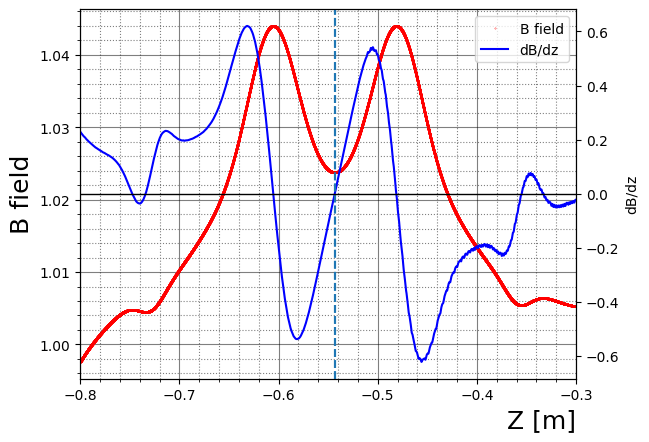

In [17]:
fig, ax1 = plt.subplots()

plotter_nicer("Z [m]", "Total Potential")
ax1.set_xlim(-0.800, -0.300)

# Primo asse y (ad esempio per il potenziale)
ax1.plot(zgrid, Bfield_20mT_pregravity_grid, linestyle="", marker = ".", markersize = 0.5, color="red", label="B field")

# Secondo asse y per la derivata
ax2 = ax1.twinx()
ax2.plot(zgrid, dBfield_20mT_pregravity_dz, color="blue", label="dB/dz")
#ax2.axvline(CONSTANTS.Zmid)

ax2.axvline(CONSTANTS.Zmid, linestyle = "--")
ax2.axvline(CONSTANTS.Zmid + 0.0005, linestyle = "--")
ax2.axhline(0., linestyle = "-", color = "black", linewidth = 1)

# Etichette
ax1.set_ylabel("B field")
ax2.set_ylabel("dB/dz")

# Se vuoi una legenda combinata:
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

In [18]:
# test gradient computation

a = dB_seg(CONSTANTS.Zmid,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

a = dB_seg(-0.51,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

[0.0,0.0,-0.0008337517196643773]
[0.0,0.0,0.5228327002899658]


## Test 3d Initial Conditions

In [19]:
from UTILS import InitialCondition_3d

In [20]:
# Initialize the particles
Z_array = []
X_array = []
Y_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []
for _ in range(nAtoms):
    #print("Extracting values:")
    Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
    # Initial position
    Z_array.append(Rinit[0])
    X_array.append(Rinit[1])
    Y_array.append(Rinit[2])
    
    V_array.append(Vinit)             # Initial speed
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

Z_array = np.array(Z_array).flatten()
V_array = np.array(V_array)
print(V_array.shape)

Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

(1000, 3)


Text(0.5, 0, 'velocity [m/s]')

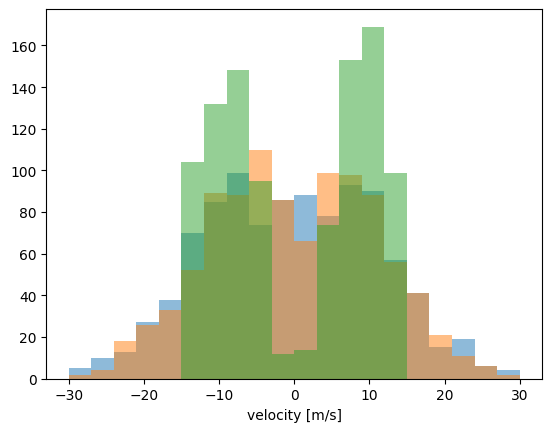

In [21]:
plt.hist(V_array[:,0], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,1], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,2], range = (-30, 30), bins = 20, alpha = .5)
plt.xlabel("velocity [m/s]")

# Test Mixing, Rotation Matrix

In [22]:
from UTILS import rotation_matrix_axis_angle, sample_random_axis

vec    = [1,0,0]
axis   = [0,0,1]

R = rotation_matrix_axis_angle(axis, np.pi/4)
vec2 = R @ vec

print(f"starting vec: {vec}; rotated Vector {vec2}")

vec  = [1,0,0]
axis = [0,1,1]

R = rotation_matrix_axis_angle(axis, np.pi/2)
vec2 = R @ vec

print(f"starting vec: {vec}; rotated Vector {vec2}")

starting vec: [1, 0, 0]; rotated Vector [0.70710678 0.70710678 0.        ]
starting vec: [1, 0, 0]; rotated Vector [ 6.12323400e-17  7.07106781e-01 -7.07106781e-01]


# Test simulation code, simulate 1 particle and follow the trajectory

In [23]:
from UTILS import step_all_particles, InitialCondition, dt, harmonic_degree, harmonic_coefficient
import time

In [24]:
# Initialize the atom
Time = 0
R_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []

Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
Vinit[1] = 0

# Initial position
R_array.append(Rinit)

V_array.append(Vinit)             # Initial speed
Time_Annihilation.append(np.nan)  # Time annihilation
Annihilation.append(False)

dB_buffer = np.empty(3, dtype=np.float64)
R_array = np.array(R_array)
V_array = np.array(V_array)
Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

In [25]:
start_time = time.time()

Xv = []
Yv = []
Zv = []

Vxv = []
Vyv = []
Vzv = []

for frame in range(0,int(0.11/dt)):

    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_20mT_pregravity_dz  # non usato
    Binit    = Bfield_20mT_pregravity_grid 
    dBfinal  = dBfield_17mT_dz             # usi questo
    Bfinal   = Bfield_17mT_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, Binit, dBfinal, Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer,
        theta, tau_mixing)

    if(frame % 1 == 0):
        print(f"frame {frame}, time {Time:.5f}s, ({R_array[0,0]*1e3:.2f},{R_array[0,1]*1e3:.2f},{ (R_array[0,2] - CONSTANTS.Zmid)*1e3:.2f}) mm, V ({V_array[0,0]:.2f},{V_array[0,1]:.2f},{V_array[0,2]:.2f})")
    
    # Get trajectory
    Xv.append(R_array[0,0])
    Yv.append(R_array[0,1])
    Zv.append(R_array[0,2])

    Vxv.append(V_array[0,0])
    Vyv.append(V_array[0,1])
    Vzv.append(V_array[0,2])
    
    # Avanza il tempo UNA volta per frame
    Time += dt

frame 0, time 0.00000s, (-1.42,0.00,0.77) mm, V (-14.24,0.00,7.70)
frame 1, time 0.00010s, (-2.85,0.00,1.54) mm, V (-14.24,0.00,7.69)
frame 2, time 0.00020s, (-4.27,0.00,2.31) mm, V (-14.24,0.00,7.67)
frame 3, time 0.00030s, (-5.70,0.00,3.07) mm, V (-14.24,0.00,7.65)
frame 4, time 0.00040s, (-7.12,0.00,3.84) mm, V (-14.23,0.00,7.63)
frame 5, time 0.00050s, (-8.54,0.00,4.60) mm, V (-14.20,0.00,7.59)
frame 6, time 0.00060s, (-9.96,0.00,5.36) mm, V (-14.14,0.00,7.56)
frame 7, time 0.00070s, (-11.37,0.00,6.11) mm, V (-14.03,0.00,7.51)
frame 8, time 0.00080s, (-12.76,0.00,6.86) mm, V (-13.81,0.00,7.46)
frame 9, time 0.00090s, (-14.13,0.00,7.60) mm, V (-13.45,0.00,7.41)
frame 10, time 0.00100s, (-15.45,0.00,8.34) mm, V (-12.87,0.00,7.34)
frame 11, time 0.00110s, (-16.71,0.00,9.07) mm, V (-11.99,0.00,7.28)
frame 12, time 0.00120s, (-17.85,0.00,9.80) mm, V (-10.73,0.00,7.20)
frame 13, time 0.00130s, (-18.85,0.00,10.51) mm, V (-9.04,0.00,7.12)
frame 14, time 0.00140s, (-19.66,0.00,11.22) mm, V 

In [26]:
print(Xv[:10])

[-0.0014239817439507714, -0.002847963016342376, -0.004271929198676966, -0.005695780790747758, -0.007119149539988784, -0.008541045313805343, -0.009959279840827628, -0.011369621485486266, -0.012764657487156376, -0.014132391394531277]


In [27]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable


In [28]:
def grid_plotter(zc, height):
    xx = np.ones(100)*zc
    zz = np.ones(100)*(height)
    yy = np.linspace(-0.0250, 0.0250, 100)
    ax.plot(xx, yy, zz, linestyle = "--", color = "black", alpha = 0.75)
    ax.plot(xx, zz, yy, linestyle = "--", color = "black", alpha = .75)

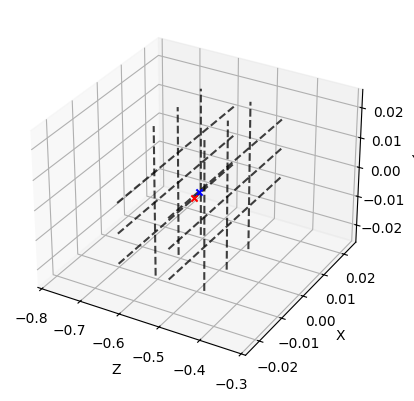

In [29]:
#%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

start = 0
end = 2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# plot starting point
ax.scatter(Zv[start], Xv[start], Yv[start], color = "blue", marker = "x")
# plot ending point
ax.scatter(Zv[end], Xv[end], Yv[end], color = "red", marker = "x")
# plot the trajectory
ax.plot(Zv[:end], Xv[:end], Yv[:end])

height = np.linspace(-0.02/2, 0.02/2, 3)

for h in height:
    grid_plotter(CONSTANTS.Zmin, h)
    grid_plotter(CONSTANTS.Zmax, h)


ax.set_xlim(-0.800, -0.300) # X axis -> Z variable
ax.set_ylim(-0.0250/1, +0.0250/1) # Y axis -> X variable
ax.set_zlim(-0.0250/1, +0.0250/1) # Z axis -> Y variable

ax.set_xlabel("Z")
ax.set_ylabel("X")
ax.set_zlabel("Y")

plt.show()

# Visualization of the motion inside the Potential Well

In [30]:
def BfieldExtended(function, X, Y, Z, k, p):
    "3d extent of the magnetic field model, assuming harmonic potential"
    r = np.sqrt(X*X + Y*Y)
    return function(Z) * (1 + k*r**p)

def slice_plotter(f, Bfield, zc, height, alpha, ax):
    zcomp = np.linspace(-0.8, -0.3, 100)
    ycomp = np.ones(100)*(0)
    xcomp = np.ones(100)*(height)
    
    Potential = f(Bfield, 
               xcomp, 
               ycomp, # y component
               zcomp, # z component
               harmonic_coefficient, harmonic_degree)*1e4
    Potential -= f(Bfield, 
               0, 
               0, # y component
               CONSTANTS.Zmid, # z component
               harmonic_coefficient, harmonic_degree)*1e4
    ax.plot(zcomp, xcomp , Potential, linestyle = "-", color = "black", alpha = alpha)

# Visualization of the Motion in the Z-X plane, with slice of the magnetic field potential

Text(0.5, 0, 'Potential')

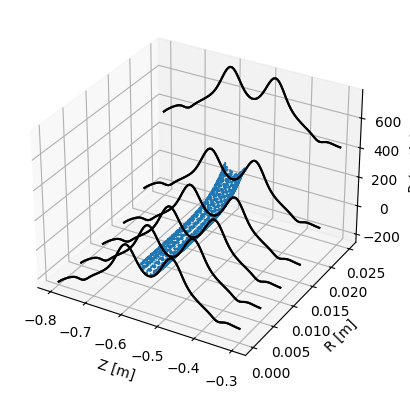

In [31]:
# fig = plt.figure(2)
# ax = fig.add_subplot(111, projection='3d')

start = 0
end = 5000

fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')

# Trajectoy in Potential
Potential = BfieldExtended(Bfield_17mT, np.array(Xv), np.array(Yv),np.array(Zv),
                           harmonic_coefficient, harmonic_degree)*1e4 

Potential -= BfieldExtended(Bfield_17mT, 0,0, CONSTANTS.Zmid,
                           harmonic_coefficient, harmonic_degree)*1e4

# Plot trajectory in the potential well
ax1.plot(Zv[:end], 
         np.sqrt(np.array(Xv[:end])**2 + np.array(Yv[:end])**2),
         Potential[:end], 
         linestyle = "dotted")

#slice


height = np.linspace(0, 0.025, 6)

for h in height:
    alpha = 1
    slice_plotter(BfieldExtended, Bfield_17mT, 0, h, alpha, ax1)
    slice_plotter(BfieldExtended, Bfield_17mT, 0, h, alpha, ax1)

# ax.set_xlim(-0.800, -0.300)
# ax.set_ylim(-0.250, +0.250)
# ax.set_zlim(-0.250, +0.250)

ax1.set_xlabel("Z [m]")
ax1.set_ylabel("R [m]")
ax1.set_zlabel("Potential")

#plt.show()

## Visualize potential

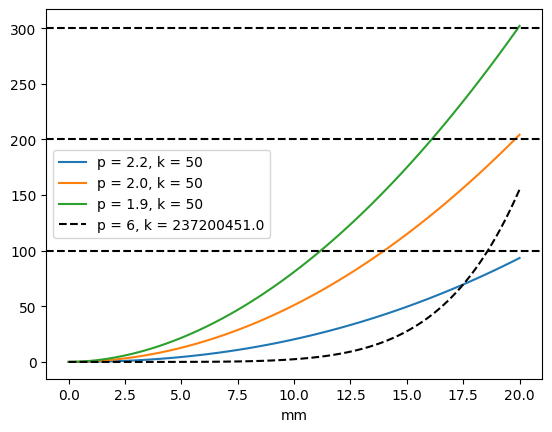

In [32]:

plt.figure(4)

x = np.linspace(0, 0.020, 100)

degree = 2.2
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 2.
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 1.9
k      = 50
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, label = f"p = {degree}, k = {k}")

degree = 6
k      = 2.37200451e8
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           k, 
                           degree) * 10000
Potential -= min(Potential)
plt.plot(x*1000, Potential, color = "black", linestyle = "--" ,label = f"p = {degree}, k = {k}")

plt.axhline(200, linestyle = "--", color = "black")
plt.axhline(300, linestyle = "--", color = "black")
plt.axhline(100, linestyle = "--", color = "black")
plt.xlabel("mm")

plt.legend()
plt.show()

In [33]:
import numpy as np
from matplotlib import pyplot as plt
from UTILS import harmonic_degree, harmonic_coefficient

In [34]:
R, Bfield = np.loadtxt("Radius.txt", unpack = True, delimiter = ",")

print(R, Bfield)

R = R # mm -> m
Bfield = Bfield

[ 0.          1.05736807  2.20472439  3.30708701  5.53430825  6.63667087
  8.84139612  9.96625559 11.09111506 12.21597453 13.31833544 14.44319491
 15.50056384 16.64792015 17.77277962 18.87514053 19.95500631 21.07986578] [ -0.74765212  -0.74765212  -1.49530423  -0.74765212  -1.49530423
  -2.24295635  -2.99066551  -2.24295635   0.74765212   2.24301339
   9.71964864  16.44863177  26.91587548  47.10282488  70.28038273
 105.42054558 152.52337046 211.58880032]


[2.37200451e+08]


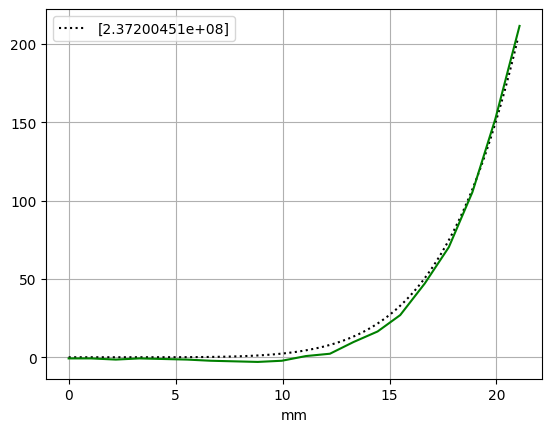

In [35]:
from scipy.optimize import curve_fit

def model(R, k):
    return (k*1e4) * R**(6)

p0 = [harmonic_coefficient, harmonic_degree]
popt, pcovm =  curve_fit(model, R*1e-3, Bfield, p0 = [harmonic_coefficient])

print(popt)

plt.figure(23)
plt.grid()
zgrid = np.linspace(0, 21, 100)
#plt.plot(zgrid, model(zgrid, 5e-11), linestyle = "dotted", color = "blue")
plt.plot(zgrid, model(zgrid*1e-3, *popt), linestyle = "dotted", color = "black", label = f"{popt}")
plt.errorbar(R, Bfield, color = "green")
plt.xlabel("mm")

plt.legend()
plt.show()